<a href="https://colab.research.google.com/github/Amirhatamian/Probability-and-Statistics-Analysis/blob/main/Arcese_Logistics2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**1. Importing Libraries and Loading Data**



In [1]:
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

# Load data
file_path = 'Input_data_timeseries (1).xlsx'
df = pd.read_excel(file_path, sheet_name='db')

# Convert ORDER DATE to datetime
df['ORDER DATE'] = pd.to_datetime(df['ORDER DATE'])


**Preprocessing**

**Aggregate Data by Week and Identify Top 5 Routes**


In [2]:
# Create weekly data
df['WEEK'] = df['ORDER DATE'].dt.to_period('W').apply(lambda r: r.start_time)
weekly_orders = df.groupby(['ROUTE', 'WEEK'])['NUMBER OF ACTUAL ORDERS'].sum().reset_index()

# Calculate average weekly orders and find top 5 routes
avg_orders_per_route = weekly_orders.groupby('ROUTE')['NUMBER OF ACTUAL ORDERS'].mean().reset_index()
avg_orders_per_route = avg_orders_per_route.rename(columns={'NUMBER OF ACTUAL ORDERS': 'AVG WEEKLY ORDERS'})
top_routes = avg_orders_per_route.nlargest(5, 'AVG WEEKLY ORDERS')


**3. Splitting Data into Training, Validation, and Testing**




In [3]:
# Filter for top routes and split data
splits = {}
for route in top_routes['ROUTE']:
    route_data = weekly_orders[weekly_orders['ROUTE'] == route].sort_values(by='WEEK')
    total_weeks = len(route_data)
    train_end = int(total_weeks * 0.6)
    val_end = int(total_weeks * 0.8)

    train = route_data[:train_end]
    val = route_data[train_end:val_end]
    test = route_data[val_end:]
    splits[route] = (train, val, test)


**4. Weekly Forecasting Using ARIMA**


In [4]:
# ARIMA Forecasting
def forecast_with_arima(train, test, p=1, d=1, q=0):
    model = ARIMA(train['NUMBER OF ACTUAL ORDERS'], order=(p, d, q))
    model_fit = model.fit()
    forecast = model_fit.forecast(steps=len(test))
    mae = mean_absolute_error(test['NUMBER OF ACTUAL ORDERS'], forecast)
    rmse = np.sqrt(mean_squared_error(test['NUMBER OF ACTUAL ORDERS'], forecast))
    return forecast, mae, rmse

# Forecasting for all routes
forecast_results = []
for route in top_routes['ROUTE']:
    train, val, test = splits[route]
    train_val = pd.concat([train, val])
    forecast, mae, rmse = forecast_with_arima(train_val, test)
    forecast_results.append({
        'Route': route,
        'Forecast': forecast.tolist(),
        'MAE': mae,
        'RMSE': rmse
    })

forecast_results_df = pd.DataFrame(forecast_results)


/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be give

**5. Summary Table**



In [6]:
# Final summary table
final_summary_table = forecast_results_df[['Route', 'Forecast', 'MAE']].copy()
final_summary_table['Forecast AVG ORDER for Next Week'] = final_summary_table['Forecast'].apply(lambda x: sum(x) / len(x))
final_summary_table = final_summary_table[['Route', 'Forecast AVG ORDER for Next Week', 'MAE']]

# Display the summary table
import warnings
warnings.filterwarnings("ignore")
print(final_summary_table)  # Simple print



                                 Route  Forecast AVG ORDER for Next Week  \
0  EAST_NORTH__ITALY_NORTH_EAST_CENTER                        487.641468   
1                     ROMANIA__BELGIUM                        487.641468   
2        ITALY_NORTH_WEST__EAST_BALCAN                        496.294037   
3                  IBERIA__ITALY_SOUTH                        436.062821   
4                GERMANY_RUHR__BELGIUM                        422.665160   

          MAE  
0  153.368741  
1  153.368741  
2  162.748583  
3  137.971912  
4  155.937887  


**6. Visualization**

Weekly Actual vs. Forecast



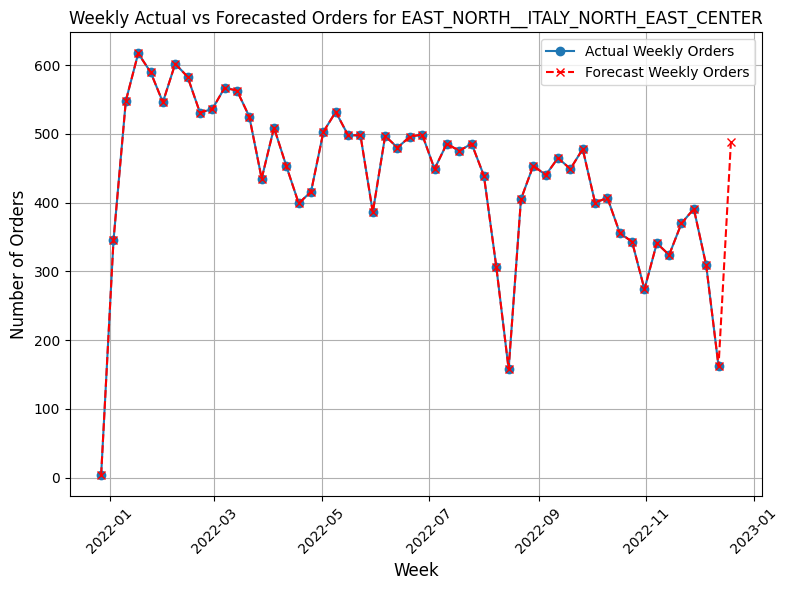

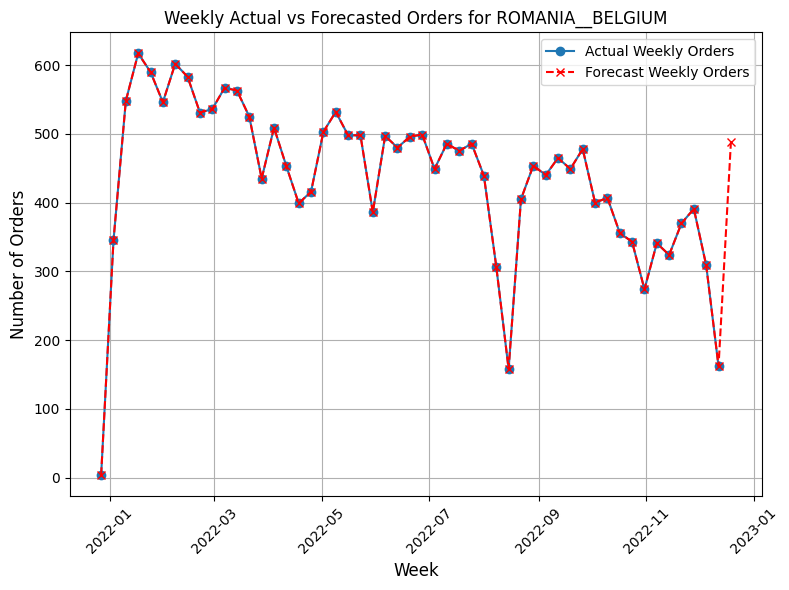

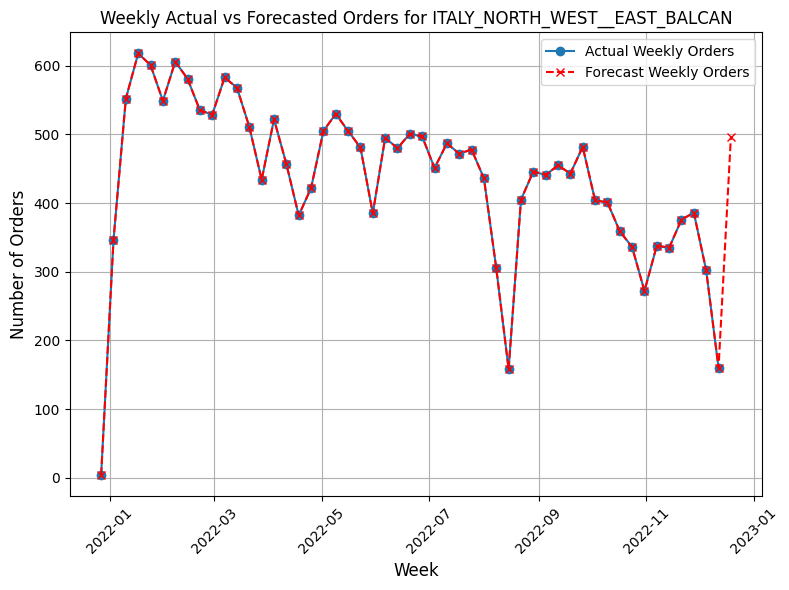

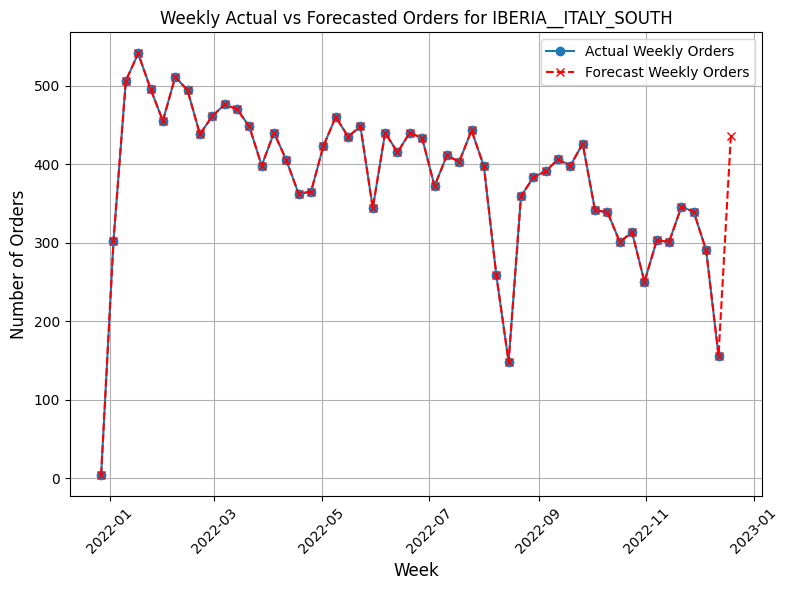

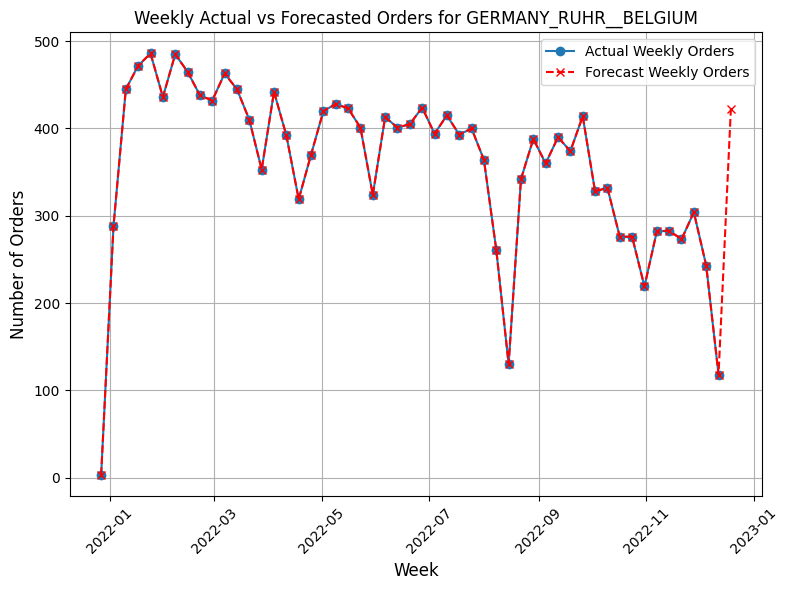

In [7]:
# Provided forecast averages for each route
forecast_avg_orders = {
    'EAST_NORTH__ITALY_NORTH_EAST_CENTER': 487.641468,
    'ROMANIA__BELGIUM': 487.641468,
    'ITALY_NORTH_WEST__EAST_BALCAN': 496.294037,
    'IBERIA__ITALY_SOUTH': 436.062821,
    'GERMANY_RUHR__BELGIUM': 422.665160,
}

# Define the corrected weekly plotting function using the provided forecast results
def plot_corrected_weekly_actual_with_forecast(route_name, actual_weekly, forecast_avg_order):
    last_week_date = actual_weekly['WEEK'].max()
    forecast_week_date = last_week_date + pd.Timedelta(weeks=1)

    # Append the forecast week to the data for plotting
    weeks = list(actual_weekly['WEEK']) + [forecast_week_date]
    orders = list(actual_weekly['NUMBER OF ACTUAL ORDERS']) + [forecast_avg_order]

    plt.figure(figsize=(8, 6))
    plt.plot(actual_weekly['WEEK'], actual_weekly['NUMBER OF ACTUAL ORDERS'], label='Actual Weekly Orders', marker='o')
    plt.plot(weeks, orders, label='Forecast Weekly Orders', linestyle='--', marker='x', color='red')
    plt.title(f"Weekly Actual vs Forecasted Orders for {route_name}", fontsize=12)
    plt.xlabel("Week", fontsize=12)
    plt.ylabel("Number of Orders", fontsize=12)
    plt.legend(fontsize=10)
    plt.grid()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Generate the corrected weekly actual vs forecast plots using the provided forecast averages
for route_name, forecast_avg_order in forecast_avg_orders.items():
    actual_weekly = weekly_orders[weekly_orders['ROUTE'] == route_name]
    plot_corrected_weekly_actual_with_forecast(route_name, actual_weekly, forecast_avg_order)